# A DLR DMFT calculation

The goal of this notebook is to make a more economical DMFT calculation using the Discrete Lehman Representation of Green's functions (DLR). If you are interested in more of the theory behind this method,a good first reference is [(here)](https://doi.org/10.1103/PhysRevB.86.085133), which this tutorial follows closely. 

You will construct first a simple self-consistent loop for the Sachdev-Ye-Kitaev model, and then an IPT calculation with a more compact and economical framework than in Tutorial 1. 

## Discrete Lehman Representation
Here we take advantage of the spectral representation of the Green's function
\begin{equation}
G(\tau)=-\int_{-\infty}^{\infty} K(\tau, \omega) \rho(\omega) d \omega
\end{equation}
with the fermionic kernel being given by 
\begin{equation}
K(\tau, \omega)=\frac{e^{-\omega \tau}}{1+e^{-\beta \omega}}
\end{equation}
The kernel $K$ can be approximated by a low rank decomposition. This has some negative consequences, such as the ill-conditioning of analytic continuation (which you make have seen in the Pade approximates used in previous tutorials), but it also has some benefits. This behaviour can be exploited to provide a compact representation of $G$. 
\begin{equation}
G(\tau) \approx G_{\mathrm{DLR}}(\tau)=\sum_{k=1}^r \frac{e^{-\omega_k \tau}}{1+e^{-\omega_k}} \widehat{g}_k=\sum_{k=1}^r \widetilde{g}_k e^{-\omega_k \tau}
\end{equation}

### Constructing DLR Green's Functions
The DLR Green's function is constructed on $r$ Matsubara frequency points which are uniquely determined (independent of $G$) by a error $\epsilon$ in the accuracy of the representation and a high-energy cutoff. $\Lambda = \beta \omega_{max}$. 
These values are given to TRIQS via the parameters  `dlr_error` and `w_max` . In general, these should be convergence criterion. 
Particular care is needed when approximating stochastic data, such as quantum Monte Carlo data, which might include statistical noise.
 For the determinstic Dyson equations solved here, these should be made quite large and small respectively. Here you will see that the representation needs only $\mathcal{O}(10^2)$ points to converge correctly, compared to $\mathcal{O}(10^8)$ with a uniform Matsubara grid. 

 The example below shows how to construct a fermionic Green's function in both Matsubara frequencies and imaginary time. 

In [4]:
from triqs.gf import *
from triqs.gf.tools import *
from triqs.operators import *
from triqs.gf.block_gf import *
from triqs.gf.descriptors import Function
import h5
import numpy as np
from triqs.plot.mpl_interface import *
import matplotlib.pyplot as plt
import matplotlib as mpl
import json, sys, os


In [5]:
params = {
    "beta": 50.0,
    "mu": 0.0,
    "alpha" : 0.5,
    "w_max": 10.0,
    "dlr_err": 1e-8, 
    "J" : 1.0,
    "max_iter": 1000,
    "threshold": 1e-8,
}

In [6]:
gf_struct =[('up',1), ('dn',1)]
iw_mesh = MeshDLRImFreq(beta=params["beta"], statistic='Fermion', w_max= params["w_max"], eps = params["dlr_err"], symmetrize = True)
# careful! does not work without symmetrize=True
G_iw   = BlockGf(mesh=iw_mesh, gf_struct=gf_struct)
G_tau = make_gf_dlr_imtime(G_iw)
Sigma_iw = G_iw.copy()
Sigma_tau = make_gf_dlr_imtime(Sigma_iw)

### A word of caution
The DLR representation now allows one to evaluate $G(\tau)$ for any $\tau$, even if it is not included in the original grid. While these are faithful representations, the current TRIQS implementation does not impose additional properties of Green's functions, such as antiperiodicity. See the below examples for some subtleties in evaluating $G(\tau)$. 

In [7]:
G_iw << SemiCircular(2)
G_tau << make_gf_dlr_imtime(G_iw)
G_dlr = make_gf_dlr(G_iw["up"]) # the DLR coefficents 

print(G_dlr(0.0)) # evaluating at tau = 0.0 for float
print(G_dlr(0))   # evaluating at iw_0 for int
print(G_dlr(50.0)) # evaluating at tau = beta gives density
print(G_dlr(45.0))  # evaluating at tau = 5.0
print(G_dlr(-5.0))  # evaluating at tau = -5.0 does not obey G(-tau) = -G(beta - tau)
print(G_dlr(-150.0)) # evaluating outside the range of the DLR coefficients does not wrap back around
print(G_dlr(150.0)) # evaluating outside the range of the DLR coefficients does not wrap back around


[[-0.50000001+2.1345501e-16j]]
[[0.00044346+2.40809328e-11j]]
[[-0.50000001-5.37912629e-16j]]
[[-0.06406086-4.89547088e-17j]]
[[-0.06406086-4.89547088e-17j]]
[[nan+nanj]]
[[nan+nanj]]


### Exercise 1 
Now we are going to evluate the self-consistent Dyson loop for the $O+1$D (impurity) Sachdev-Ye-Kitaev (SYK) model. The Hamiltonian is given by 
$$H = \sum^N_{ijkl} J_{ijkl} c^\dagger_i c^\dagger_j c_k c_l$$
where the $J_{ijkl}$ couplings between $N$ fermions that are random Gaussian couplings with constant variance $J^2$.
 This model has many interesting applications for non-Fermi liquids, or strange metals, and quantum criticality. You can read more about the model and its' extensions [(here)](https://doi-org.myaccess.library.utoronto.ca/10.1103/RevModPhys.94.035004). Here we are just interested in the simple form of the self-energy in the large-$N$ limit of the model which is exactly solvable. Here we have (up to some prefactors)
\begin{equation}
\Sigma(\tau) = -J^2 G^2(\tau)G(-\tau)
\end{equation}
which has a superficial resemble to the IPT equations (except with the local $G$ rather than the Weiss $\mathcal{G}_0$). Now it is your turn to write a self-consistent loop to solve for $G$. 

In [8]:
G_iw << SemiCircular(1.0)
G_tau << make_gf_dlr_imtime(G_iw)
error = 1.0
iter = 0
while error > params["threshold"]:
    for block, g in G_tau:
        Sigma_tau[block].data[:,0,0] = params["J"]**2/4 * g.data[:,0,0]**2*np.flip(g.data[:,0,0])
        #Sigma_tau[block].data[:,0,0] = params["J"] * g.data[:,0,0]**3 # works only for particle hole symmetric systems

    Sigma_iw << make_gf_dlr_imfreq(Sigma_tau)   
    for block, g in G_tau:

        G_iw[block] << inverse(iOmega_n - Sigma_iw[block])
    G_old = G_tau.copy()
    G_tau << params["alpha"]*G_old + (1-params["alpha"])*make_gf_dlr_imtime(G_iw)
    #G_tau << make_gf_dlr_imtime(G_iw)
    error = np.mean(np.abs((G_tau["up"].data[:,0,0] - G_old["up"].data[:,0,0]) / G_old["up"].data[:,0,0]))
    # right now the spin blocks are the same / irrelevant. 
    iter += 1
    if iter % 5 == 0:
        print(error, iter)
    if iter > params["max_iter"]:
        print("Maximum number of iterations reached without convergence")
        break

0.001559070505714749 5
1.0349249103620503e-05 10
1.8579473901673987e-07 15


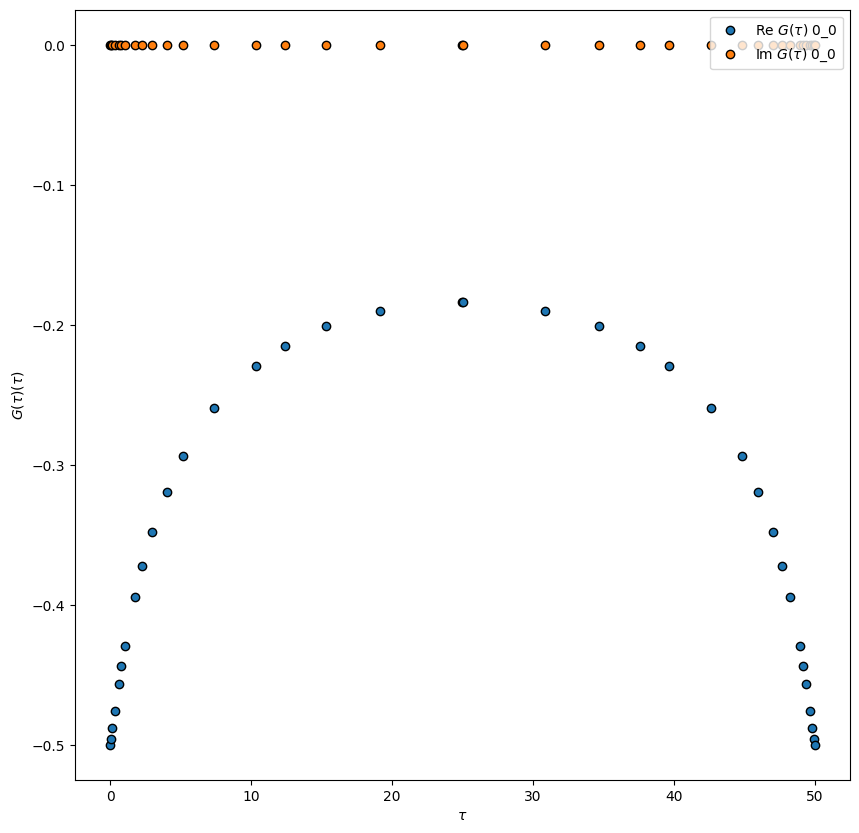

In [9]:
plt.figure(figsize = (10,10))
oplot(G_tau["up"], marker = "o", markeredgecolor = "black", name = r"$G(\tau)$")
plt.show()

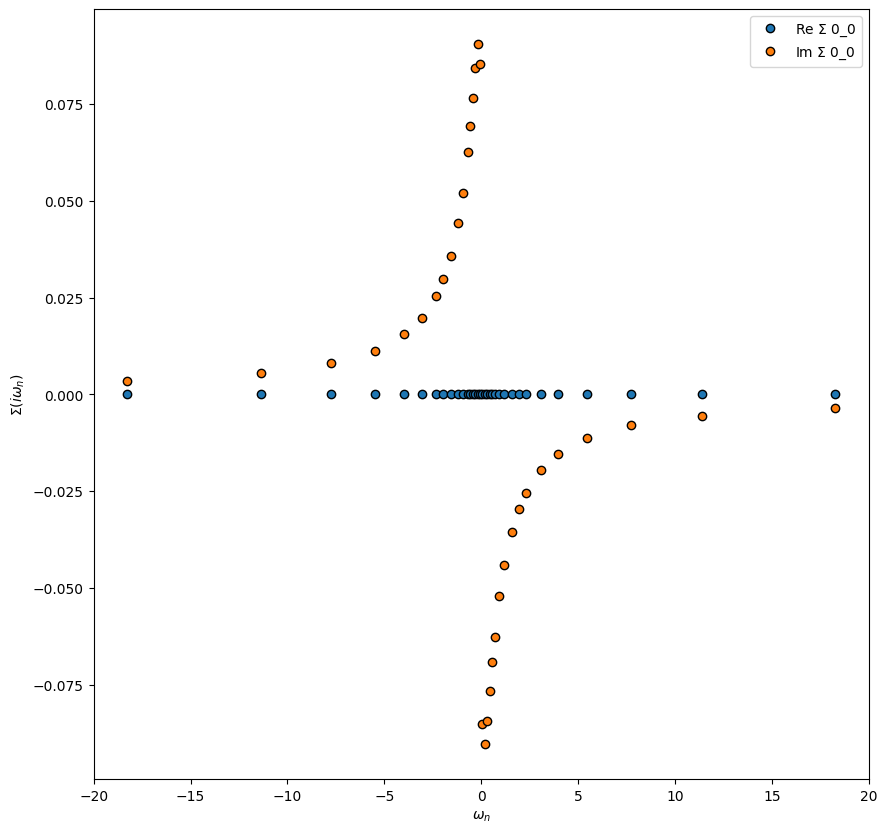

In [10]:
plt.figure(figsize = (10,10))
oplot(Sigma_iw["up"], marker = "o", markeredgecolor = "black", name = r"$\Sigma$")
plt.xlim(-20,20)
plt.show()

### Optional Exercise 1b
To really see the power of DLR, try converging these equations down to lower $T$. To do this, take a higher $T$ solution as a guess and continue lowering $T$. Steps of $\beta = 50$ should be slow enough, although you can optimize this with your $\alpha$ mixing parameter.  As you approach the $\beta = \infty$ limit, your result should begin to match the conformal solution to these equations. Try comparing!
\begin{equation}
G_c(\tau)=-\frac{\pi^{1 / 4}}{\sqrt{2 \beta}}\left(\sin \left(\frac{\pi \tau}{\beta}\right)\right)^{-1 / 2}
\end{equation}

In [15]:
params = {
    "beta": 50.0,
    "mu": 0.0,
    "alpha" : 0.80,
    "w_max": 20.0,
    "dlr_err": 1e-10, 
    "J" : 1.0,
    "max_iter": 1000,
    "threshold": 1e-8,
}

In [16]:
betas = np.array([50.0,100.0, 150.0, 250.0, 350.0,400.0,450.0 ,500.0])


In [17]:
for i, beta in enumerate(betas):
    gf_struct =[('up',1), ('dn',1)]
    params["beta"] = beta
 
    iw_mesh = MeshDLRImFreq(beta=params["beta"], statistic='Fermion', w_max= params["w_max"], eps = params["dlr_err"], symmetrize = True)
    # careful! does not work without symmetrize=True

    G_iw   = BlockGf(mesh=iw_mesh, gf_struct=gf_struct)
    G_tau = make_gf_dlr_imtime(G_iw)

    if i == 0:
        G_iw << SemiCircular(2)
    if i > 1:
        tau = np.array([x.real for x in G_tau.mesh.values()], dtype=np.float64)
        old_tau = np.array([x.real for x in G_old.mesh.values()], dtype=np.float64)
        old_beta = np.max(old_tau)
        tau_prime = tau*old_beta/params["beta"]
        G_dlr = make_gf_dlr(G_old)
        for block, g in G_tau:
            g.data[:,0,0] = np.array([G_dlr["up"](t)[0,0] for t in tau_prime])
        G_iw << make_gf_dlr_imfreq(G_tau)
    G_tau << make_gf_dlr_imtime(G_iw)
    Sigma_iw = G_iw.copy()
    Sigma_tau = make_gf_dlr_imtime(Sigma_iw)
    error = 1.0
    iter = 0
    while error > params["threshold"]:
        for block, g in G_tau:
            Sigma_tau[block].data[:,0,0] = params["J"]**2/4 * g.data[:,0,0]**2*np.flip(g.data[:,0,0])
            #Sigma_tau[block].data[:,0,0] = params["J"] * g.data[:,0,0]**3 # works only for particle hole symmetric systems

        Sigma_iw << make_gf_dlr_imfreq(Sigma_tau)   
        for block, g in G_tau:

            G_iw[block] << inverse(iOmega_n - Sigma_iw[block])
        G_old = G_tau.copy()
        G_tau << params["alpha"]*G_old + (1-params["alpha"])*make_gf_dlr_imtime(G_iw)
        #G_tau << make_gf_dlr_imtime(G_iw)
        idx = np.where(G_old["up"].data[:,0,0] == 0.0)[0]
        G_old["up"].data[idx,0,0] = 1.0
        error = np.mean(np.abs((G_tau["up"].data[:,0,0] - G_old["up"].data[:,0,0]) / G_old["up"].data[:,0,0]))
        # right now the spin blocks are the same / irrelevant. 
        iter += 1
        if iter % 20 == 0:
            print(error, iter, params["beta"])
        if iter > params["max_iter"]:
            print("Maximum number of iterations reached without convergence")
            break
    G_old = G_tau.copy()

0.00018642980121496007 20 50.0
1.0551719818406181e-06 40 50.0
0.0010133481924638882 20 100.0
9.020256563906696e-06 40 100.0
9.256213401949465e-08 60 100.0
1.2355223139904116e-05 20 150.0
5.130730897831215e-08 40 150.0
1.3878098026234743e-05 20 250.0
5.989698240910868e-08 40 250.0
9.581600005583062e-06 20 350.0
4.130081612291154e-08 40 350.0
4.113186540783512e-06 20 400.0
1.7995074533369348e-08 40 400.0
3.6162068025034036e-06 20 450.0
1.608034789948581e-08 40 450.0
3.390955130622913e-06 20 500.0
1.43680989989107e-08 40 500.0


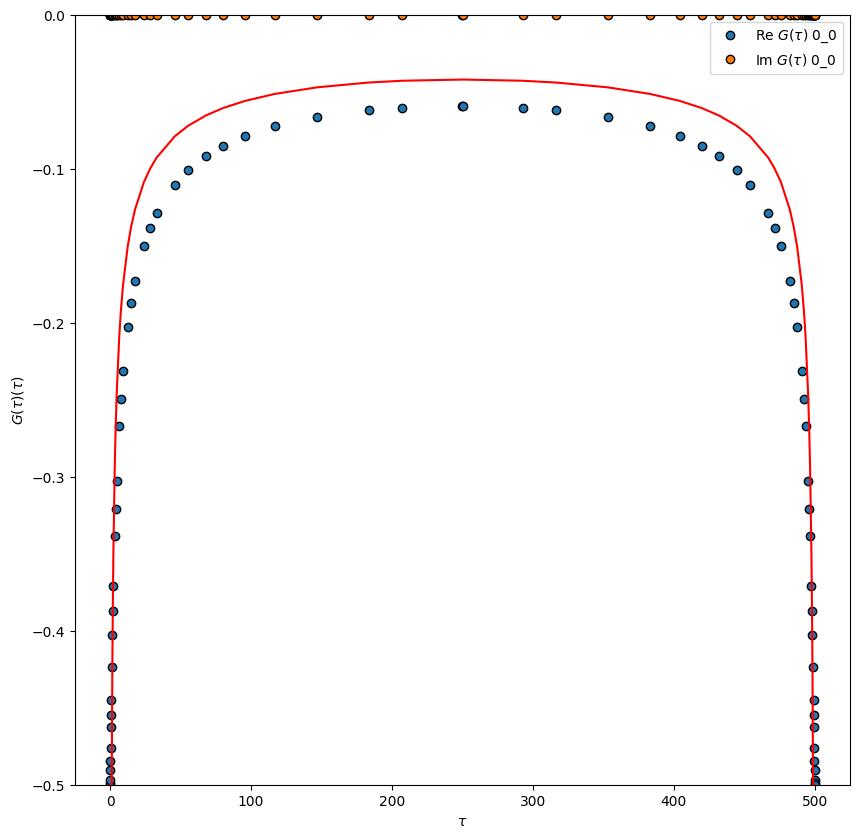

In [ ]:
plt.figure(figsize = (10,10))
t =  np.array([x.real for x in G_tau.mesh.values()])
Gconformal = -np.pi**(1/4) / np.sqrt(2*params["beta"]) * 1/np.sqrt(np.sin(np.pi * t / params["beta"]))
oplot(G_tau["up"], marker = "o", markeredgecolor = "black", name = r"$G(\tau)$")
plt.plot(t, Gconformal, label = r"$G_{conformal}(\tau)$", color = "red")
plt.ylim(-0.5,0)
plt.show()

### Exercise 2 

Now that you see the power of DLR, try repeating Tutorial 1 to converge the IPT equations for a given $\beta$ and $U$. See how much quicker your calculations are compared to Tutorial 1. 


In [ ]:

from triqs.gf import *
import numpy as np
from triqs.operators import *

class IPTSolver:
    def __init__(self, params):
        self.params = params
        # Matsubara frequency Green's functions
        iw_mesh = MeshDLRImFreq(beta=params["beta"], statistic='Fermion', w_max= params["w_max"], eps =params["dlr_err"], symmetrize = True)
        self.G_iw = BlockGf(mesh=iw_mesh, gf_struct = [('up',1), ('dn',1)] )
        self.G0_iw = self.G_iw.copy() # self.G0 will be set by the user after initialization
        self.Sigma_iw = self.G_iw.copy()

        # Imaginary time
        tau_mesh = MeshDLRImTime(beta=params["beta"], statistic='Fermion', w_max= params["w_max"], eps =params["dlr_err"], symmetrize = True)
        self.G0_tau = BlockGf(mesh=tau_mesh, gf_struct = [('up',1), ('dn',1)] )
        self.G_tau = self.G0_tau.copy()
        self.Sigma_tau = self.G0_tau.copy()

    def solve(self):
        error = 1.0
        iter = 0

        
            


In [ ]:
params = {
    "beta": 50.0,
    "mu": 0.0,
    "alpha" : 0.5,
    "w_max": 10.0,
    "dlr_err": 1e-8, 
    "U" : 3.0, # In the Mott state, U > 4, you run into trouble, but this is also why the IPT tutorial just stops at small iteration number. 
    "t" : 1.0,
    "max_iter": 1000, # small iteration number is ~ 25
    "threshold": 1e-8,
}

In [ ]:
S = IPTSolver(params)
S.G_iw << SemiCircular(2*params["t"])


Green Function G composed of 2 blocks: 
 Greens Function G_up with mesh DLR imfreq mesh of size 36 with beta = 50, statistic = Fermion, w_max = 10, eps = 1e-08 and target_shape (1, 1): 
 
 Greens Function G_dn with mesh DLR imfreq mesh of size 36 with beta = 50, statistic = Fermion, w_max = 10, eps = 1e-08 and target_shape (1, 1): 
 

In [ ]:
error = 1.0
iter = 0
while error > params["threshold"]:
    print("Iteration:", iter)
    for block, g in S.G0_iw:
        g << inverse( iOmega_n - params["t"]**2 * S.G_iw[block] )
    S.G0_tau << make_gf_dlr_imtime(S.G0_iw)
    S.Sigma_tau << (params["U"]**2) * S.G0_tau * S.G0_tau * S.G0_tau
    S.Sigma_iw << make_gf_dlr_imfreq(S.Sigma_tau)
    G_old = S.G_iw.copy()
    S.G_iw << inverse(inverse(S.G0_iw) - S.Sigma_iw)
    S.G_iw << params["alpha"]*S.G_iw+ (1-params["alpha"])*G_old
    G_tau_old = S.G_tau.copy()
    S.G_tau << make_gf_dlr_imtime(S.G_iw)
    error = np.mean(np.abs((S.G_tau["up"].real.data[:,0,0] - G_tau_old["up"].real.data[:,0,0]) / G_tau_old["up"].real.data[:,0,0]))

    iter += 1
    if iter % 5 == 0:
        print(error, iter)
    if iter > params["max_iter"]:
        print("Maximum number of iterations reached without convergence")
        break

Iteration: 0
Iteration: 1
Iteration: 2
Iteration: 3
Iteration: 4
0.0016821665998838229 5
Iteration: 5
Iteration: 6
Iteration: 7
Iteration: 8
Iteration: 9
3.707673734909233e-05 10
Iteration: 10
Iteration: 11
Iteration: 12
Iteration: 13
Iteration: 14
8.68261338822299e-07 15
Iteration: 15
Iteration: 16
Iteration: 17
Iteration: 18
Iteration: 19
2.081733772436832e-08 20
Iteration: 20


/tmp/ipykernel_109476/735204175.py:15: RuntimeWarning: divide by zero encountered in divide
  error = np.mean(np.abs((S.G_tau["up"].real.data[:,0,0] - G_tau_old["up"].real.data[:,0,0]) / G_tau_old["up"].real.data[:,0,0]))


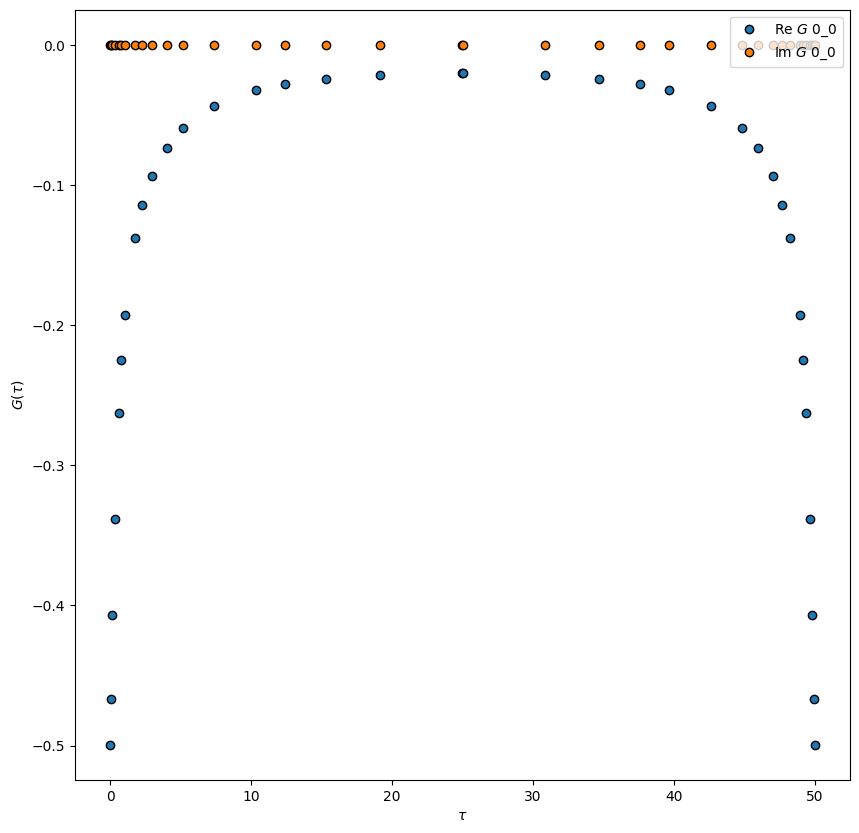

In [ ]:
plt.figure(figsize = (10,10))
oplot(S.G_tau["up"], marker = "o", markeredgecolor = "black", name = r"$G$")
plt.show()

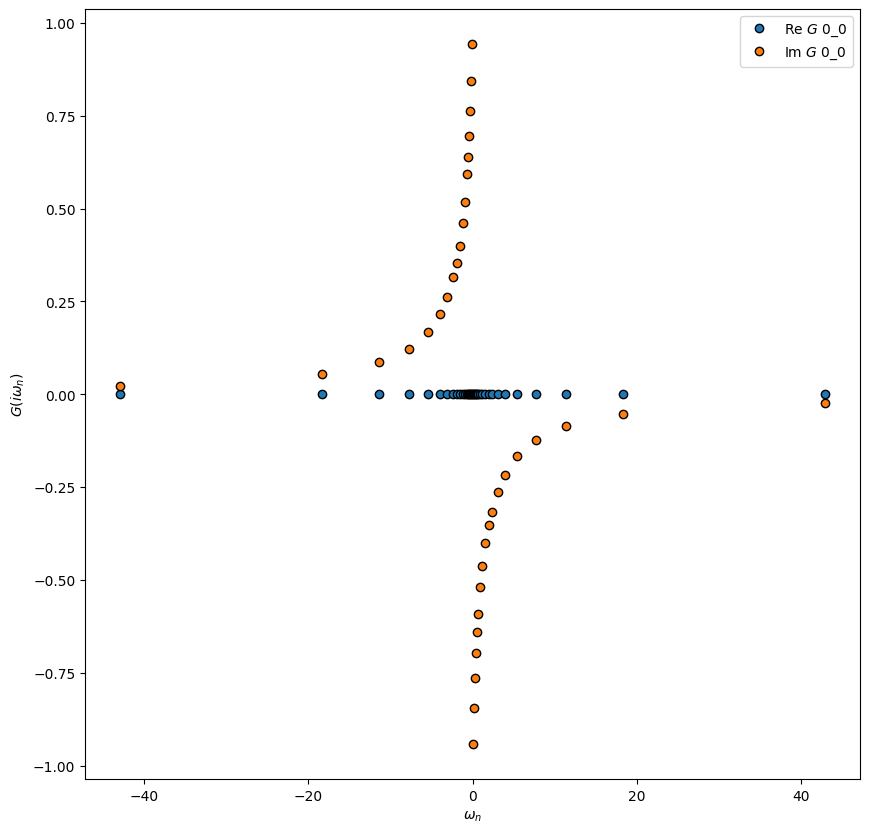

In [ ]:
plt.figure(figsize = (10,10))
oplot(S.G_iw["up"], marker = "o", markeredgecolor = "black", name = r"$G$")
plt.show()

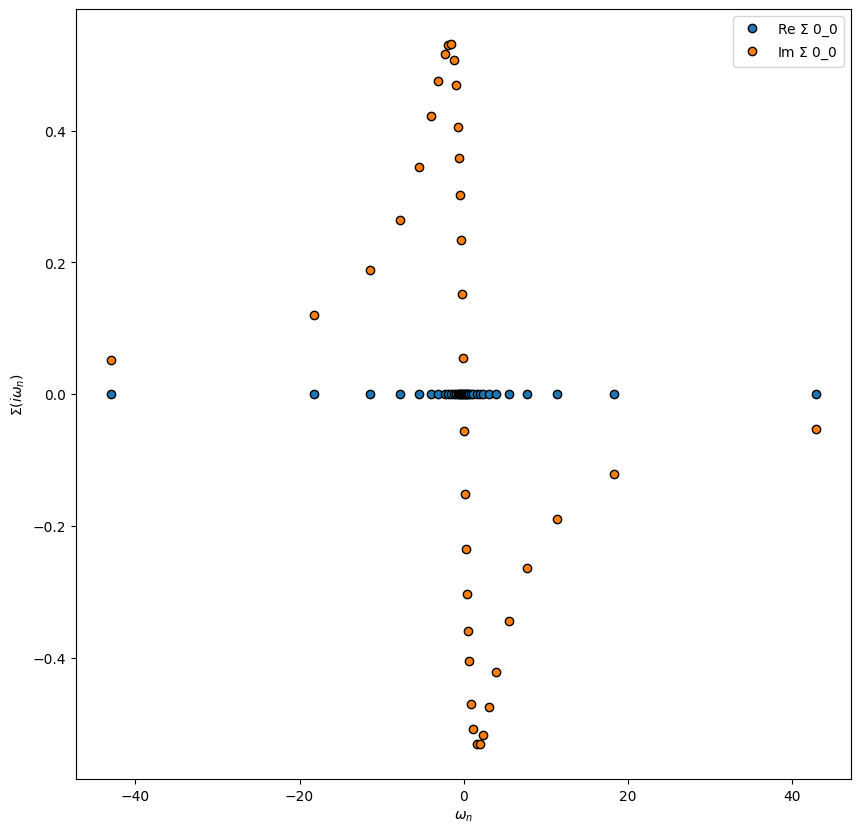

In [ ]:
plt.figure(figsize = (10,10))
oplot(S.Sigma_iw["up"], marker = "o", markeredgecolor = "black", name = r"$\Sigma$")
plt.show()

In [ ]:
G_w = Gf(mesh=MeshReFreq(window = (-5.0,5.0), n_w=1000), target_shape=[1,1])
G_iw = make_gf_imfreq(S.G_iw["up"], n_iw = 2**14+3)
G_w.set_from_pade(G_iw, 100, 0.01)

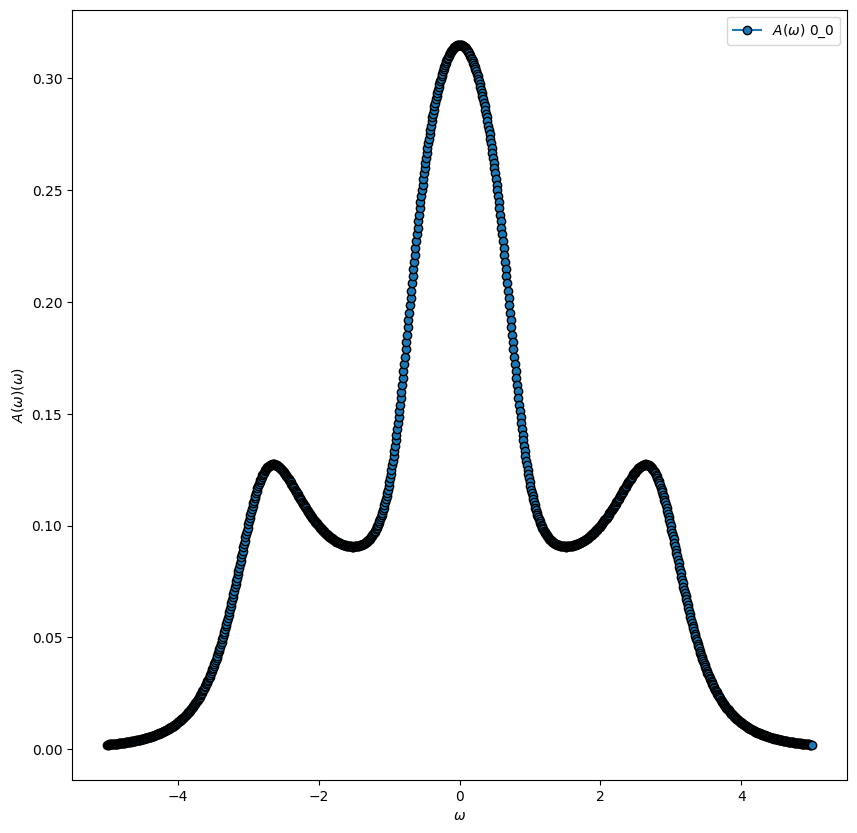

In [ ]:
plt.figure(figsize = (10,10))
oplot(-np.imag(G_w)/np.pi, marker = "o", markeredgecolor = "black", name = r"$A(\omega)$")
plt.show()